In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Carregando do dataset de cancer de mama
cancer = load_breast_cancer()

X = cancer.data # Características do tumor
y = cancer.target # Classe do tumor

In [4]:
# Transformando em dataframe
df = pd.DataFrame(X, columns=cancer.feature_names)

df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
# Informações gerais do dataset
print("Informações do dataset:")
print("-----------------------------------------")
print("Shape do dataset:", df.shape) # Número de linhas e colunas
print("-----------------------------------------")
print("Classes:", cancer.target_names) # Classes presentes no dataset
print("-----------------------------------------")
print("Features:", cancer.feature_names) # Nomes das características

Informações do dataset:
-----------------------------------------
Shape do dataset: (569, 31)
-----------------------------------------
Classes: ['malignant' 'benign']
-----------------------------------------
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


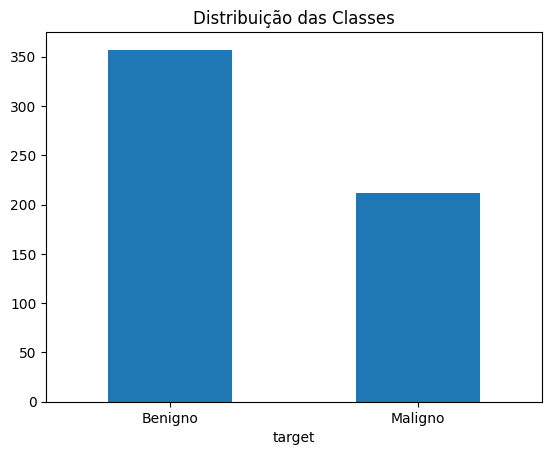

In [9]:
# Explorando os dados com gráfico
df['target'].value_counts().plot(kind='bar')

plt.title("Distribuição das Classes")
plt.xticks([0, 1], ['Benigno', 'Maligno'], rotation=0)

plt.show()

In [10]:
# Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# Padronização com StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Testando K de 1 até 20
k_values = []
accuracies = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k) # Criando o modelo KNN com o valor de k atual

    knn.fit(X_train_scaled, y_train) # Treinando o modelo com os dados de treino padronizados

    y_pred = knn.predict(X_test_scaled) # Fazendo previsões com os dados de teste padronizados

    acc = accuracy_score(y_test, y_pred) # Calculando a acurácia das previsões

    k_values.append(k) # Armazenando o valor de k
    accuracies.append(acc) # Armazenando a acurácia correspondente ao valor de k

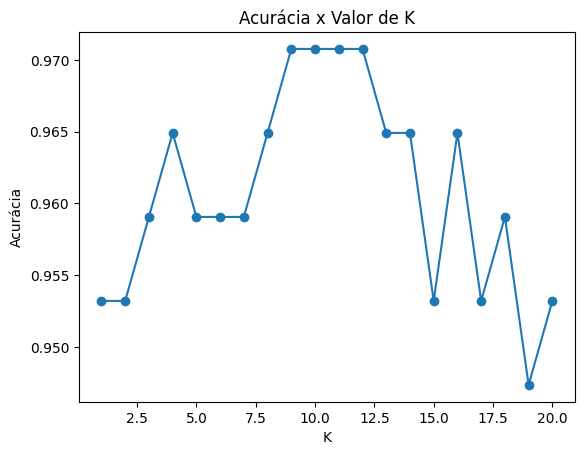

In [13]:
# Gráfico Acurácia × K
plt.plot(k_values, accuracies, marker='o')

plt.title("Acurácia x Valor de K")
plt.xlabel("K")
plt.ylabel("Acurácia")

plt.show()

In [ ]:
# Escolhendo o melhor K (com base na acurácia)
best_k = k_values[accuracies.index(max(accuracies))]

print("Se considerarmos que:")
print("K muito baixo: sensível demais")
print("K muito alto: perde precisão")
print("Melhor K:", best_k)

Se considerarmos que:
K muito baixo: sensível demais
K muito alto: perde precisão
Melhor K: 9


In [18]:
# Treinando o modelo final com o melhor K
final_model = KNeighborsClassifier(n_neighbors=best_k)

final_model.fit(X_train_scaled, y_train)

final_predictions = final_model.predict(X_test_scaled)

In [22]:
# Classification report do modelo final
print("Classification Report do Modelo Final:")
print(classification_report(y_test, final_predictions, target_names=cancer.target_names))

Classification Report do Modelo Final:
              precision    recall  f1-score   support

   malignant       0.97      0.95      0.96        63
      benign       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



## Conclusão

O modelo KNN apresentou bons resultados na classificação do dataset breast cancer.

A utilização do StandardScaler foi importante para melhorar o desempenho do algoritmo, já que o KNN utiliza cálculo de distância entre os dados.

Após testar diferentes valores de K, foi possível escolher o que apresentou melhor acurácia.